# CatBoost Ensemble Version 2

In [1]:
import os
import numpy as np
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
import joblib
import time
import sys
sys.path.append("..")
from utils.metrics import evaluate, compare_splits

SEED = 67
np.random.seed(SEED)

In [2]:
FEAT_PATH   = "../features/ensemble"
DENSE_PATH  = "../features/dense"
MODEL_PATH  = "../models"

os.makedirs(MODEL_PATH, exist_ok=True)

# Loading Data

In [3]:
X_train_ens = np.load(os.path.join(FEAT_PATH, "X_train.npy"))
X_val_ens   = np.load(os.path.join(FEAT_PATH, "X_val.npy"))
X_test_ens  = np.load(os.path.join(FEAT_PATH, "X_test.npy"))

y_train = np.load(os.path.join(FEAT_PATH, "y_train.npy"))
y_val   = np.load(os.path.join(FEAT_PATH, "y_val.npy"))
y_test  = np.load(os.path.join(FEAT_PATH, "y_test.npy"))

print("Ensemble feature shapes:")
print(f"  X_train : {X_train_ens.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val_ens.shape}    y_val   : {y_val.shape}")
print(f"  X_test  : {X_test_ens.shape}   y_test  : {y_test.shape}")

Ensemble feature shapes:
  X_train : (65891, 2400)   y_train : (65891,)
  X_val   : (4380, 2400)    y_val   : (4380,)
  X_test  : (17596, 2400)   y_test  : (17596,)


In [4]:
X_train_dense = np.load(os.path.join(DENSE_PATH, "dense_train_feat.npy"))
X_val_dense   = np.load(os.path.join(DENSE_PATH, "dense_val_feat.npy"))
X_test_dense  = np.load(os.path.join(DENSE_PATH, "dense_test_feat.npy"))

print("DenseNet121 feature shapes:")
print(f"  X_train_dense : {X_train_dense.shape}")
print(f"  X_val_dense   : {X_val_dense.shape}")
print(f"  X_test_dense  : {X_test_dense.shape}")

DenseNet121 feature shapes:
  X_train_dense : (65891, 1024)
  X_val_dense   : (4380, 1024)
  X_test_dense  : (17596, 1024)


In [5]:
X_train = np.concatenate([X_train_ens, X_train_dense], axis=1)
X_val   = np.concatenate([X_val_ens,   X_val_dense],   axis=1)
X_test  = np.concatenate([X_test_ens,  X_test_dense],  axis=1)

print("Fused feature shapes (ensemble + DenseNet121):")
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}   y_test  : {y_test.shape}")
print(f"  Classes : {len(np.unique(y_train))}")

Fused feature shapes (ensemble + DenseNet121):
  X_train : (65891, 3424)   y_train : (65891,)
  X_val   : (4380, 3424)    y_val   : (4380,)
  X_test  : (17596, 3424)   y_test  : (17596,)
  Classes : 38


In [6]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(MODEL_PATH, "ensemble_scaler_v2.pkl"))
print("Scaler saved")
print(f"X_train mean~0: {X_train.mean():.4f}  std~1: {X_train.std():.4f}")

Scaler saved
X_train mean~0: 0.0000  std~1: 1.0000


# Model Training

In [7]:
model = CatBoostClassifier(iterations=800, learning_rate=0.07, depth=6, loss_function="MultiClass", border_count=128,
    l2_leaf_reg=3, eval_metric="Accuracy", random_seed=SEED, early_stopping_rounds=50, verbose=50, task_type="GPU", devices="0")

start=time.time()

model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

t=time.time()-start

print("\nBest iteration:", model.get_best_iteration())
print(f"Total Time Taken : {t:.2f}s")

0:	learn: 0.2088297	test: 0.2077626	best: 0.2077626 (0)	total: 658ms	remaining: 8m 45s
50:	learn: 0.9135542	test: 0.9038813	best: 0.9038813 (50)	total: 35.6s	remaining: 8m 43s
100:	learn: 0.9560031	test: 0.9431507	best: 0.9431507 (99)	total: 1m 10s	remaining: 8m 6s
150:	learn: 0.9720751	test: 0.9593607	best: 0.9595890 (144)	total: 1m 43s	remaining: 7m 26s
200:	learn: 0.9800428	test: 0.9655251	best: 0.9662100 (190)	total: 2m 16s	remaining: 6m 45s
250:	learn: 0.9842164	test: 0.9694064	best: 0.9694064 (250)	total: 2m 45s	remaining: 6m 2s
300:	learn: 0.9866294	test: 0.9712329	best: 0.9712329 (284)	total: 3m 14s	remaining: 5m 22s
350:	learn: 0.9888452	test: 0.9726027	best: 0.9737443 (347)	total: 3m 42s	remaining: 4m 44s
400:	learn: 0.9907878	test: 0.9748858	best: 0.9748858 (399)	total: 4m 10s	remaining: 4m 8s
450:	learn: 0.9921841	test: 0.9755708	best: 0.9760274 (444)	total: 4m 37s	remaining: 3m 34s
500:	learn: 0.9932464	test: 0.9769406	best: 0.9769406 (484)	total: 5m 4s	remaining: 3m 1s
55

In [8]:
model_file = os.path.join(MODEL_PATH, "catboost_ensemble_v2.cbm")
model.save_model(model_file)
print("Model saved:", model_file)

Model saved: ../models/catboost_ensemble_v2.cbm


# Model Evaluation

TRAINING DATA

===== METRICS =====


Metrics,Value
Accuracy,0.995295
Precision,0.995288
Recall,0.995285
F1_Score,0.995282
ROC_AUC,0.999990
Log_loss,0.061461



============================ CONFUSION MATRIX =============================


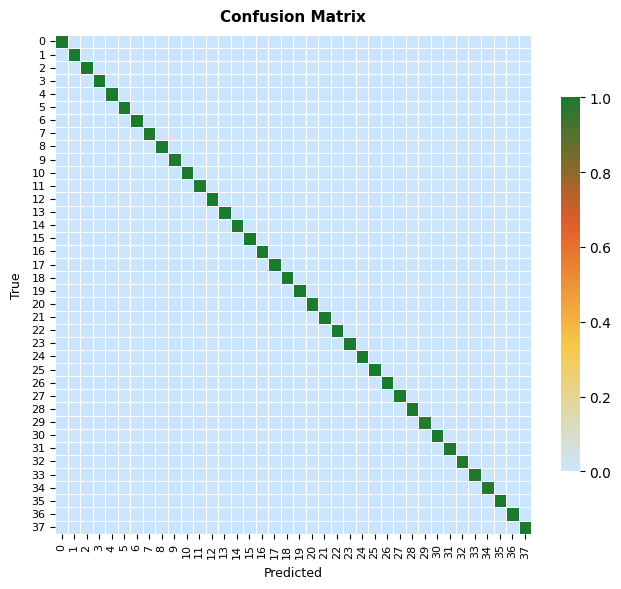


==================================== ROC CURVE ====================================


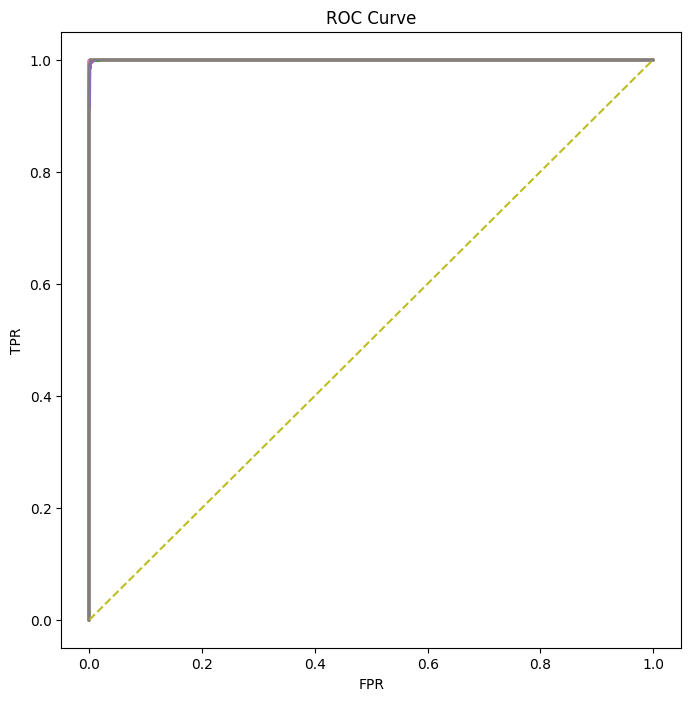

In [9]:
print("TRAINING DATA")
train_pred  = model.predict(X_train).flatten().astype(int)
train_proba = model.predict_proba(X_train)
train_metrics = evaluate(y_train, train_pred, train_proba)

VALIDATION DATA

===== METRICS =====


Metrics,Value
Accuracy,0.980822
Precision,0.980863
Recall,0.980783
F1_Score,0.980700
ROC_AUC,0.999867
Log_loss,0.100442



============================ CONFUSION MATRIX =============================


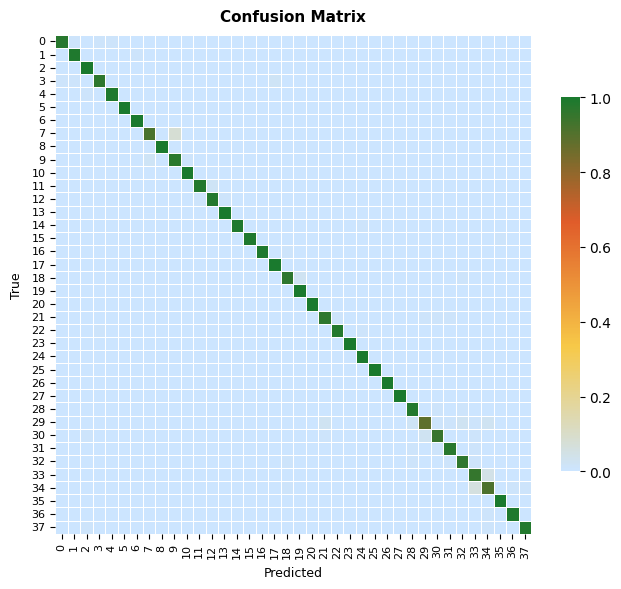


==================================== ROC CURVE ====================================


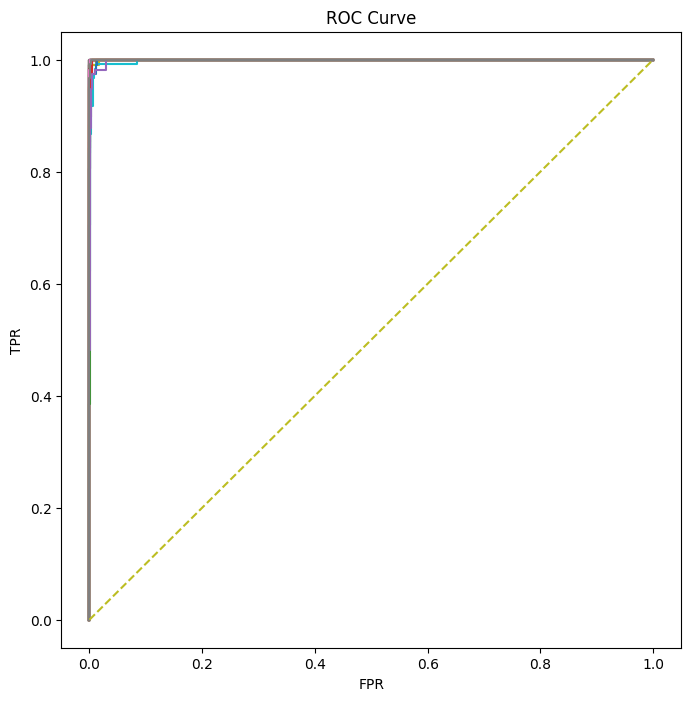

In [10]:
print("VALIDATION DATA")
val_pred  = model.predict(X_val).flatten().astype(int)
val_proba = model.predict_proba(X_val)
val_metrics = evaluate(y_val, val_pred, val_proba)

TESTING DATA

===== METRICS =====


Metrics,Value
Accuracy,0.981359
Precision,0.981405
Recall,0.981188
F1_Score,0.981225
ROC_AUC,0.999893
Log_loss,0.096801



============================ CONFUSION MATRIX =============================


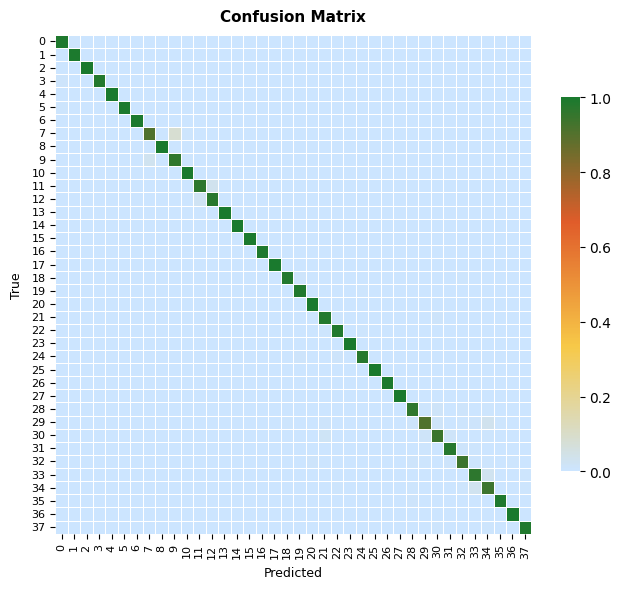


==================================== ROC CURVE ====================================


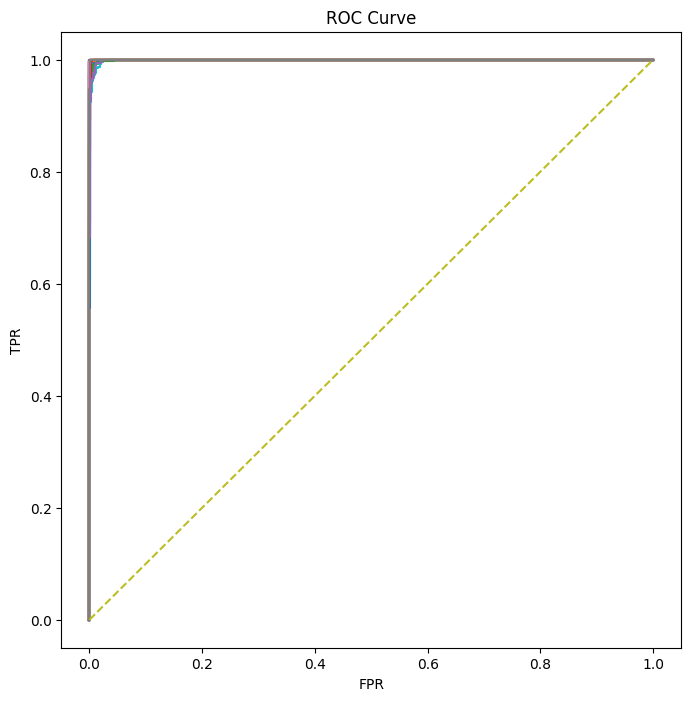

In [11]:
print("TESTING DATA")
test_pred  = model.predict(X_test).flatten().astype(int)
test_proba = model.predict_proba(X_test)
test_metrics = evaluate(y_test, test_pred, test_proba)


================ SPLIT COMPARISON ================


,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Log_loss
train,0.9953,0.9953,0.9953,0.9953,1.0000,0.0615
val,0.9808,0.9809,0.9808,0.9807,0.9999,0.1004
test,0.9814,0.9814,0.9812,0.9812,0.9999,0.0968


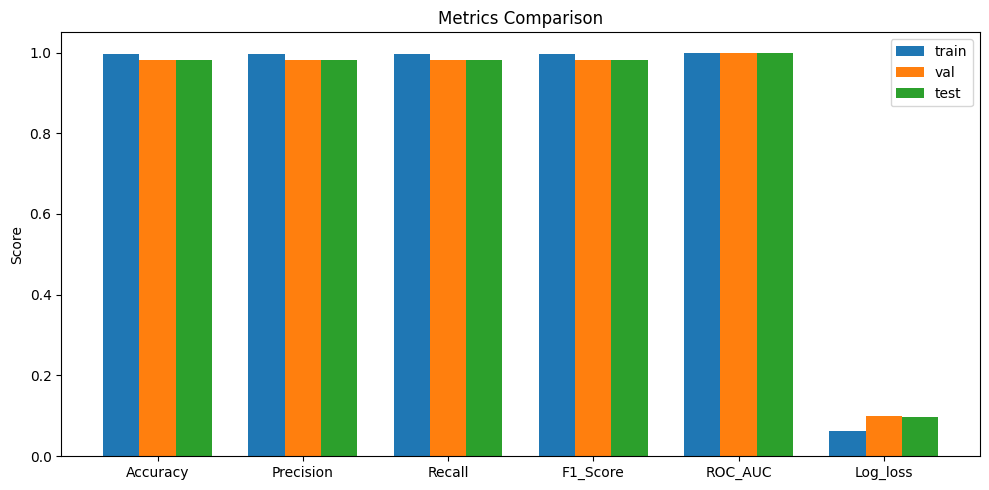

In [12]:
df_comparison = compare_splits(train_metrics, val_metrics, test_metrics)

## Feature Importance

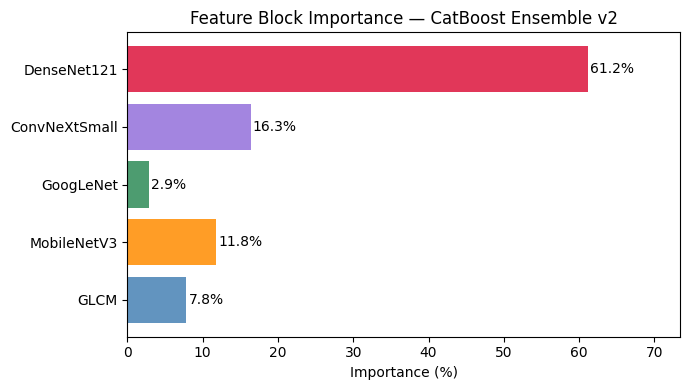

Block importance:
  GLCM           : 7.84%
  MobileNetV3    : 11.76%
  GoogLeNet      : 2.87%
  ConvNeXtSmall  : 16.35%
  DenseNet121    : 61.17%


In [13]:
import matplotlib.pyplot as plt

importances = model.get_feature_importance()

dims = {"GLCM": 32, "MobileNetV3": 576, "GoogLeNet": 1024, "ConvNeXtSmall": 768, "DenseNet121": 1024}

block_importance = {} 
start = 0
for name, dim in dims.items():
    block_importance[name] = importances[start:start + dim].sum()
    start += dim

total    = sum(block_importance.values())
block_pct = {k: (v / total) * 100 for k, v in block_importance.items()}

plt.figure(figsize=(7, 4))
colors = ["steelblue", "darkorange", "seagreen", "mediumpurple", "crimson"]
bars = plt.barh(list(block_pct.keys()), list(block_pct.values()), color=colors, alpha=0.85)

plt.xlabel("Importance (%)")
plt.title("Feature Block Importance — CatBoost Ensemble v2")
plt.xlim(0, max(block_pct.values()) * 1.2)

for bar, val in zip(bars, block_pct.values()):
    plt.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.show()

print("Block importance:")
for k, v in block_pct.items():
    print(f"  {k:<15}: {v:.2f}%")